# Control variates for a GARCH model

This notebook implements:

1. a random-walk Metropolis sampler targeting a Bayesian GARCH(1,1) posterior;
2. zero-variance control variates of Mira, Solgi and Imparato (2013);
3. a larger polynomial control set and a Lasso screening step inspired by Leluc, Portier and Segers (2021);
4. repeated-run boxplots and empirical standard deviations to assess numerical error.

The real-data example uses EUR/USD reference rates downloaded from Frankfurter and stored locally in `data/`.

## Sources used

- Mira, A., Solgi, R. and Imparato, D. (2013), *Zero Variance Markov Chain Monte Carlo for Bayesian Estimators*, Statistics and Computing 23, 653--662. DOI: `10.1007/s11222-012-9344-6`.
- Leluc, R., Portier, F. and Segers, J. (2021), *Control variate selection for Monte Carlo integration*, Statistics and Computing 31, article 50. DOI: `10.1007/s11222-021-10011-z`.
- Frankfurter exchange-rate API documentation, used for the EUR/USD daily rates.

## Model and posterior

We use the Gaussian GARCH(1,1) recursion

\[
r_t\mid \mathcal F_{t-1}\sim \mathcal N(0,h_t),\qquad
h_t=\omega_1+\omega_2 r_{t-1}^2+\omega_3 h_{t-1}.
\]

The posterior is proportional to the Gaussian quasi-likelihood times independent centered normal priors on
\((\omega_1,\omega_2,\omega_3)\), restricted to
\(\omega_1>0,\omega_2>0,\omega_3>0,\omega_2+\omega_3<0.995\).

To remove boundary issues in the zero-variance formula and to avoid rejected negative proposals, the chain is run on an unconstrained vector \(\theta\), transformed to \(\omega\).  The target density in \(\theta\) includes the Jacobian of this transformation.  Posterior summaries are still reported in the original GARCH parameters.

In [1]:
import json
import pathlib
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = pathlib.Path.cwd()
SRC = ROOT / "src"
sys.path.insert(0, str(SRC))

import garch_cv as g
from experiment import make_cv_estimates, run_dataset
from report_utils import latex_float, write_latex_table, write_compact_latex_table

warnings.filterwarnings("ignore", category=UserWarning)
np.set_printoptions(precision=4, suppress=True)

FIG_DIR = ROOT / "figures"
RESULT_DIR = ROOT / "results"
FIG_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

In [2]:
# Reproducible experiment settings.
TRUE_OMEGA = np.array([0.04, 0.08, 0.88])
N_SIM = 600
N_REP = 10
N_STEPS = 8000
BURN_IN = 2000
THIN = 3
LARGE_DEGREE = 5
SEED_BASE = 20260504
USE_CACHED_RESULTS = True
CACHE_SIGNATURE = {
    "n_rep": N_REP,
    "n_steps": N_STEPS,
    "burn_in": BURN_IN,
    "thin": THIN,
    "large_degree": LARGE_DEGREE,
    "seed_base": SEED_BASE,
    "n_sim": N_SIM,
    "proposal": "pilot_full_covariance_v1",
}

simulated_returns, simulated_h = g.simulate_garch(N_SIM, TRUE_OMEGA, seed=SEED_BASE)

fx = pd.read_csv(ROOT / "data" / "eurusd_frankfurter_2023_2024.csv", parse_dates=["date"])
real_returns = g.prepare_returns_from_prices(fx["eur_usd"].to_numpy())
real_dates = fx["date"].iloc[1:].to_numpy()

print(f"Simulated sample: {len(simulated_returns)} returns")
print(f"EUR/USD sample: {len(real_returns)} daily log-returns from {fx['date'].min().date()} to {fx['date'].max().date()}")
print(f"EUR/USD return sd, in percent: {real_returns.std(ddof=1):.3f}")

Simulated sample: 600 returns
EUR/USD sample: 511 daily log-returns from 2022-12-30 to 2024-12-31
EUR/USD return sd, in percent: 0.434


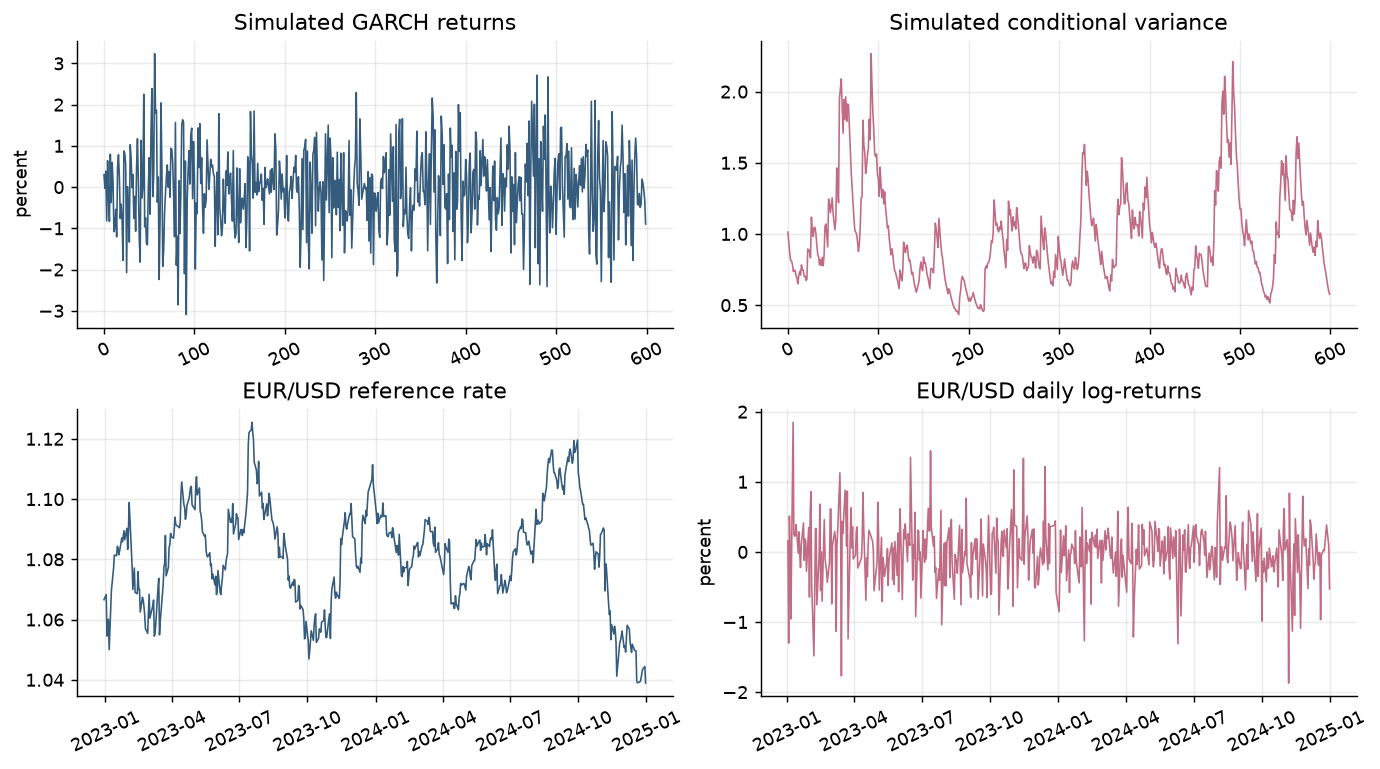

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(10.5, 5.8), constrained_layout=True)
ax[0, 0].plot(simulated_returns, lw=0.9, color="#355C7D")
ax[0, 0].set_title("Simulated GARCH returns")
ax[0, 0].set_ylabel("percent")
ax[0, 1].plot(simulated_h, lw=0.9, color="#C06C84")
ax[0, 1].set_title("Simulated conditional variance")
ax[1, 0].plot(fx["date"], fx["eur_usd"], lw=0.9, color="#355C7D")
ax[1, 0].set_title("EUR/USD reference rate")
ax[1, 1].plot(real_dates, real_returns, lw=0.9, color="#C06C84")
ax[1, 1].set_title("EUR/USD daily log-returns")
ax[1, 1].set_ylabel("percent")
for axis in ax.ravel():
    axis.tick_params(axis="x", labelrotation=25)
fig.savefig(FIG_DIR / "data_overview.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "data_overview.png", bbox_inches="tight")
plt.show()

## Additional data plots

The next plots show why a conditional-variance model is reasonable.  The histograms summarize the marginal returns; the autocorrelation panels compare the raw returns with squared returns.  In a GARCH-type series, raw returns often have weak autocorrelation, while squared returns retain visible dependence.

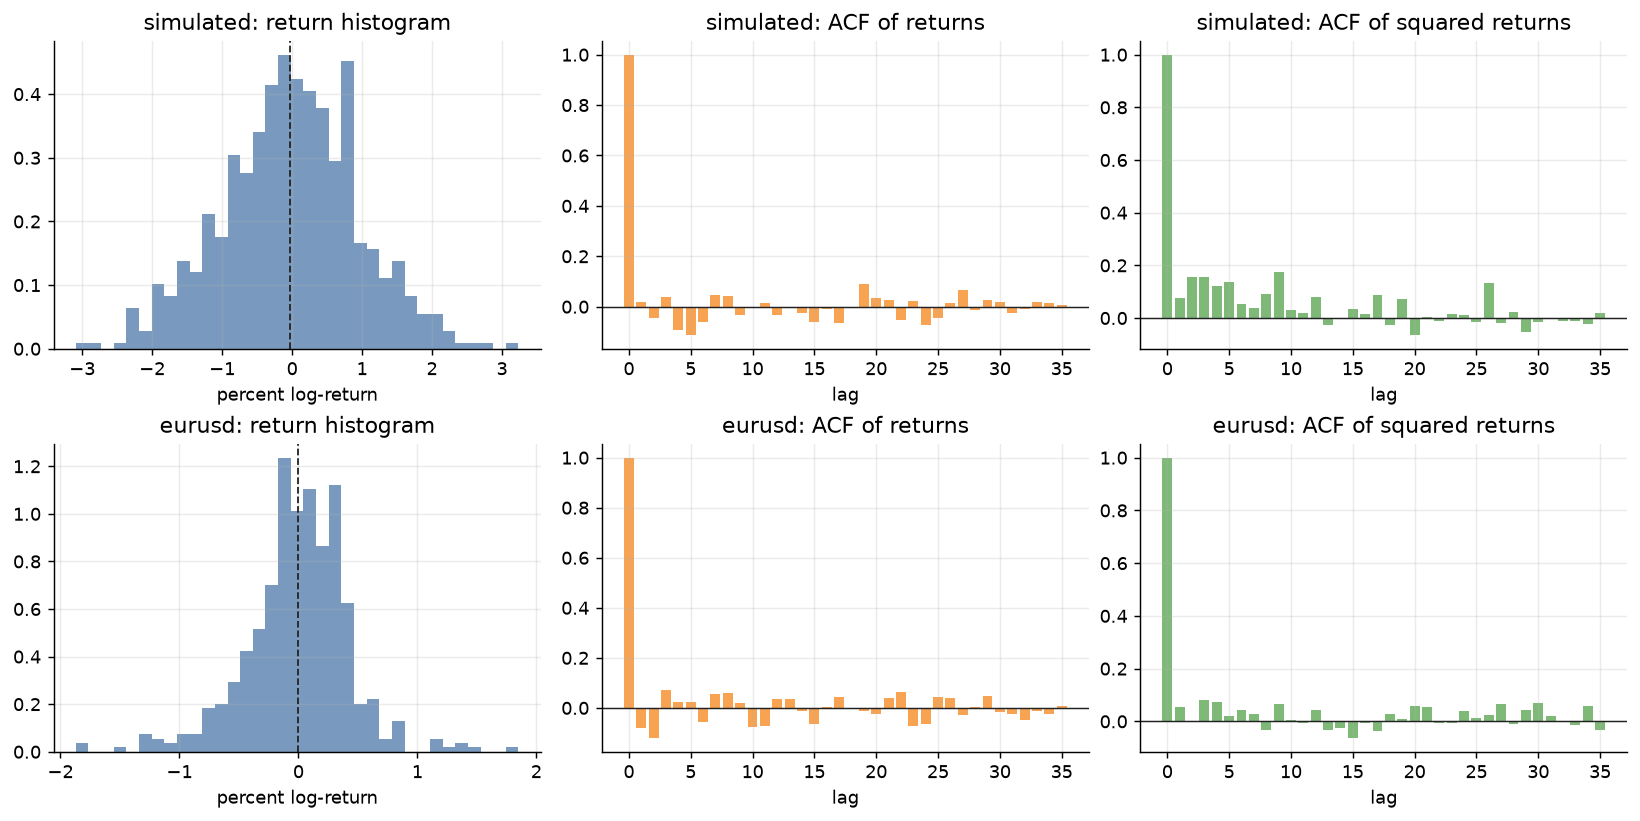

In [4]:
def plot_data_diagnostics():
    datasets = {
        "simulated": simulated_returns,
        "eurusd": real_returns,
    }
    fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.2), constrained_layout=True)
    for row, (dataset, values) in enumerate(datasets.items()):
        axes[row, 0].hist(values, bins=35, density=True, color="#4C78A8", alpha=0.75)
        axes[row, 0].axvline(values.mean(), color="#222222", lw=1.0, ls="--")
        axes[row, 0].set_title(f"{dataset}: return histogram")
        axes[row, 0].set_xlabel("percent log-return")

        acf_returns = g.autocorrelation(values, max_lag=35)
        acf_squared = g.autocorrelation(values**2, max_lag=35)
        lags = np.arange(acf_returns.size)
        axes[row, 1].bar(lags, acf_returns, color="#F58518", alpha=0.75)
        axes[row, 1].axhline(0.0, color="#222222", lw=0.8)
        axes[row, 1].set_title(f"{dataset}: ACF of returns")
        axes[row, 1].set_xlabel("lag")

        axes[row, 2].bar(lags, acf_squared, color="#54A24B", alpha=0.75)
        axes[row, 2].axhline(0.0, color="#222222", lw=0.8)
        axes[row, 2].set_title(f"{dataset}: ACF of squared returns")
        axes[row, 2].set_xlabel("lag")
    fig.savefig(FIG_DIR / "data_diagnostics.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / "data_diagnostics.png", bbox_inches="tight")
    plt.show()

plot_data_diagnostics()

## Random-walk Metropolis sampler

The proposal is \(\theta'=\theta+\epsilon\).  We first run a diagonal random-walk pilot, then use the empirical covariance of that pilot to build a full-covariance Gaussian proposal.  This follows the TD guidance that a random-walk proposal should be scaled to the shape of the target, and it matters here because \(\omega_1\) and \(\omega_3\) are strongly correlated.  The repeated experiment below also uses longer chains than the first draft: \(8000\) iterations, burn-in \(2000\), and thinning by \(3\).  The table below checks the analytic gradient used by the control variates against a central finite difference.

In [5]:
init = {
    "simulated": TRUE_OMEGA,
    "eurusd": g.initial_omega_for_returns(real_returns),
}
returns_by_dataset = {
    "simulated": simulated_returns,
    "eurusd": real_returns,
}
proposal_start = {
    "simulated": np.array([0.16, 0.10, 0.10]),
    "eurusd": np.array([0.16, 0.10, 0.10]),
}

tuning_rows = []
tuned_scales = {}
for dataset, returns in returns_by_dataset.items():
    init_theta = g.omega_to_theta(init[dataset])
    diagonal_scale, diagonal_rates = g.tune_rwm_scale(
        returns,
        init_theta,
        proposal_start[dataset],
        seed=SEED_BASE + len(dataset),
        n_rounds=5,
        round_steps=650,
    )
    proposal_cov, cov_rates, pilot_acceptance = g.tune_rwm_covariance(
        returns,
        init_theta,
        diagonal_scale,
        seed=SEED_BASE + 97 + len(dataset),
        pilot_steps=2500,
        pilot_burn_in=500,
        n_rounds=4,
        round_steps=700,
    )
    tuned_scales[dataset] = proposal_cov
    grad_a, grad_fd, grad_diff = g.check_theta_gradient(returns, init_theta)
    tuning_rows.append({
        "dataset": dataset,
        "initial_omega": np.array2string(init[dataset], precision=4),
        "diagonal_scale": np.array2string(diagonal_scale, precision=4),
        "proposal_cov_diag": np.array2string(np.diag(proposal_cov), precision=4),
        "diag_pilot_acceptance": ", ".join(f"{x:.2f}" for x in diagonal_rates),
        "cov_pilot_acceptance": f"{pilot_acceptance:.2f}; " + ", ".join(f"{x:.2f}" for x in cov_rates),
        "max_gradient_error": grad_diff,
    })

tuning_table = pd.DataFrame(tuning_rows)
tuning_table

,dataset,initial_omega,diagonal_scale,proposal_cov_diag,diag_pilot_acceptance,cov_pilot_acceptance,max_gradient_error
0,simulated,[0.04 0.08 0.88],[0.3125 0.1953 0.1953],[0.3183 0.8404 0.7414],"0.53, 0.48, 0.40, 0.32, 0.29","0.33; 0.35, 0.23, 0.21, 0.22",2.208509e-09
1,eurusd,[0.0075 0.08 0.88 ],[0.25 0.1562 0.1562],[0.2181 0.1654 0.4217],"0.50, 0.42, 0.30, 0.32, 0.33","0.33; 0.32, 0.34, 0.24, 0.17",2.021869e-09


## Gradient of the GARCH likelihood

The zero-variance controls require \(\nabla \log \pi\).  For the likelihood part, write
\[
\ell(\omega)=-\frac12\sum_{t=1}^T\left\{\log h_t+\frac{r_t^2}{h_t}\right\},
\qquad
h_t=\omega_1+\omega_2 r_{t-1}^2+\omega_3 h_{t-1}.
\]
Let \(D_{t,k}=\partial h_t/\partial\omega_k\).  With fixed initial variance \(h_1\), \(D_{1,k}=0\), and for \(t\ge2\)
\[
D_{t,1}=1+\omega_3D_{t-1,1},\qquad
D_{t,2}=r_{t-1}^2+\omega_3D_{t-1,2},\qquad
D_{t,3}=h_{t-1}+\omega_3D_{t-1,3}.
\]
Therefore
\[
\frac{\partial\ell}{\partial\omega_k}
=\frac12\sum_{t=1}^T
\left(\frac{r_t^2}{h_t^2}-\frac1{h_t}\right)D_{t,k}.
\]
The prior contributes \(-\omega_k/\sigma_k^2\).  Since the sampler runs in \(\theta\), the code finally applies the chain rule
\[
\nabla_\theta \log\pi_\theta(\theta)
=
J_{\omega}(\theta)^\top\nabla_\omega \log\pi_\omega(\omega(\theta))
+\nabla_\theta \log \left|\det J_{\omega}(\theta)\right|.
\]

## Zero-variance controls

Mira, Solgi and Imparato use

\[
\tilde f(x)= f(x)-\frac12\Delta P(x)+\nabla P(x)^\top z(x),
\qquad
z(x)=-\frac12 \nabla\log\pi(x).
\]

For a first-order polynomial \(P(x)=a^\top x\), this reduces to \(f(x)+a^\top z(x)\).
The coefficients can be estimated by the regression of \(f\) on the control vector.  In the notebook code, `MC` is the raw posterior mean, `ZV-OLS-1` is the first-order version, `ZV-OLS-2` uses all controls up to degree 2, `ZV-OLS-5` uses all controls up to degree 5, and `ZV-Lasso-5` first screens the degree-5 dictionary by Lasso and then refits OLS on the selected controls.

In [6]:
cache_path = RESULT_DIR / "repeated_estimates.csv"
cache_meta_path = RESULT_DIR / "repeated_estimates_meta.json"
representatives = {}
cache_is_current = False
if cache_path.exists() and cache_meta_path.exists():
    cache_is_current = json.loads(cache_meta_path.read_text(encoding="utf-8")) == CACHE_SIGNATURE

if USE_CACHED_RESULTS and cache_is_current:
    estimates = pd.read_csv(cache_path)
    print(f"Loaded cached repeated estimates from {cache_path}")
    for dataset, returns in returns_by_dataset.items():
        representatives[dataset] = g.run_rwm_theta(
            returns,
            g.omega_to_theta(init[dataset]),
            tuned_scales[dataset],
            n_steps=N_STEPS,
            burn_in=BURN_IN,
            thin=THIN,
            seed=SEED_BASE + (11 if dataset == "simulated" else 22),
        )
else:
    results = []
    for dataset, returns in returns_by_dataset.items():
        df, representative = run_dataset(dataset, returns, init[dataset], tuned_scales[dataset], N_REP, N_STEPS, BURN_IN, THIN, SEED_BASE)
        results.append(df)
        representatives[dataset] = representative
    estimates = pd.concat(results, ignore_index=True)
    estimates.to_csv(cache_path, index=False)
    cache_meta_path.write_text(json.dumps(CACHE_SIGNATURE, indent=2), encoding="utf-8")
estimates.head()

Loaded cached repeated estimates from /home/tom/Projects/tom/MC/results/repeated_estimates.csv


,dataset,acceptance_rate,rep,parameter,method,estimate,batch_se,selected_controls,condition_number
0,simulated,0.228,1,omega_1,MC,0.111432,0.002222,0,NaN
1,simulated,0.228,1,omega_1,ZV-OLS-1,0.109318,0.000622,3,8.158116
2,simulated,0.228,1,omega_1,ZV-OLS-2,0.108894,0.000310,9,100.519434
3,simulated,0.228,1,omega_1,ZV-OLS-5,0.108072,0.000011,55,548000.700484
4,simulated,0.228,1,omega_1,ZV-Lasso-5,0.108123,0.000035,31,18484.487818


In [7]:
# Save raw repeated-run estimates for auditability.
estimates.to_csv(RESULT_DIR / "repeated_estimates.csv", index=False)

summary = (
    estimates
    .groupby(["dataset", "parameter", "method"], as_index=False)
    .agg(
        mean_estimate=("estimate", "mean"),
        numerical_sd=("estimate", "std"),
        mean_batch_se=("batch_se", "mean"),
        mean_selected=("selected_controls", "mean"),
        median_condition=("condition_number", "median"),
        mean_acceptance=("acceptance_rate", "mean"),
    )
)
mc_sd = summary[summary["method"] == "MC"][["dataset", "parameter", "numerical_sd"]].rename(columns={"numerical_sd": "mc_sd"})
summary = summary.merge(mc_sd, on=["dataset", "parameter"], how="left")
summary["variance_reduction"] = (summary["mc_sd"] / summary["numerical_sd"]) ** 2
summary.loc[summary["method"] == "MC", "variance_reduction"] = 1.0

# Add reference columns: data-generating value for simulated data, pooled raw MC for EUR/USD.
reference = {}
for j, param in enumerate(g.PARAMETER_NAMES):
    reference[("simulated", param)] = TRUE_OMEGA[j]
    reference[("eurusd", param)] = estimates.query("dataset == 'eurusd' and method == 'MC' and parameter == @param")["estimate"].mean()
summary["reference"] = [reference[(row.dataset, row.parameter)] for row in summary.itertuples()]
summary["rmse_to_reference"] = np.nan
for idx, row in summary.iterrows():
    vals = estimates[
        (estimates["dataset"] == row["dataset"]) &
        (estimates["parameter"] == row["parameter"]) &
        (estimates["method"] == row["method"])
    ]["estimate"].to_numpy()
    summary.loc[idx, "rmse_to_reference"] = np.sqrt(np.mean((vals - row["reference"]) ** 2))

summary.to_csv(RESULT_DIR / "summary.csv", index=False)
summary

,dataset,parameter,method,mean_estimate,numerical_sd,mean_batch_se,mean_selected,median_condition,mean_acceptance,mc_sd,variance_reduction,reference,rmse_to_reference
0,eurusd,omega_1,MC,0.081957,0.007720,0.005661,0.0,NaN,0.362513,0.007720,1.000000,0.081957,0.007324
1,eurusd,omega_1,ZV-Lasso-5,0.074761,0.001943,0.000233,41.2,2.621881e+05,0.362513,0.007720,15.782792,0.081957,0.007428
2,eurusd,omega_1,ZV-OLS-1,0.081986,0.007716,0.005406,3.0,8.518630e+00,0.362513,0.007720,1.001035,0.081957,0.007320
3,eurusd,omega_1,ZV-OLS-2,0.080273,0.004199,0.002848,9.0,1.304911e+02,0.362513,0.007720,3.379594,0.081957,0.004325
4,eurusd,omega_1,ZV-OLS-5,0.074665,0.002148,0.000173,55.0,1.397916e+07,0.362513,0.007720,12.919883,0.081957,0.007571
5,eurusd,omega_2,MC,0.088909,0.003257,0.003099,0.0,NaN,0.362513,0.003257,1.000000,0.088909,0.003090
6,eurusd,omega_2,ZV-Lasso-5,0.088667,0.000762,0.000152,30.0,2.767726e+04,0.362513,0.003257,18.293031,0.088909,0.000762
7,eurusd,omega_2,ZV-OLS-1,0.088357,0.001733,0.001437,3.0,8.518630e+00,0.362513,0.003257,3.531305,0.088909,0.001735
8,eurusd,omega_2,ZV-OLS-2,0.088264,0.000951,0.000729,9.0,1.304911e+02,0.362513,0.003257,11.724723,0.088909,0.001109
9,eurusd,omega_2,ZV-OLS-5,0.089895,0.001258,0.000069,55.0,1.397916e+07,0.362513,0.003257,6.705057,0.088909,0.001548


In [8]:
sim_table = summary[summary["dataset"] == "simulated"]
real_table = summary[summary["dataset"] == "eurusd"]
write_latex_table(sim_table, RESULT_DIR / "summary_simulated.tex")
write_latex_table(real_table, RESULT_DIR / "summary_eurusd.tex")

controls_growth = pd.DataFrame({
    "degree": list(range(1, 8)),
    "number_of_controls": [g.count_polynomial_controls(3, d) for d in range(1, 8)],
})
controls_growth.to_csv(RESULT_DIR / "controls_growth.csv", index=False)

variance_summary = summary.copy()
variance_summary["empirical_variance"] = variance_summary["numerical_sd"] ** 2

first_order_variance = variance_summary[
    variance_summary["method"].isin(["MC", "ZV-OLS-1"])
][["dataset", "parameter", "method", "empirical_variance", "variance_reduction"]]
first_order_variance.to_csv(RESULT_DIR / "first_order_variance.csv", index=False)
write_compact_latex_table(first_order_variance, RESULT_DIR / "first_order_variance.tex")

step3_variance = variance_summary[
    variance_summary["method"].isin(["ZV-OLS-1", f"ZV-OLS-{LARGE_DEGREE}", f"ZV-Lasso-{LARGE_DEGREE}"])
][["dataset", "parameter", "method", "empirical_variance", "variance_reduction", "mean_selected", "median_condition"]]
step3_variance.to_csv(RESULT_DIR / "step3_variance.csv", index=False)
write_compact_latex_table(step3_variance, RESULT_DIR / "step3_variance.tex")

controls_growth

,degree,number_of_controls
0,1,3
1,2,9
2,3,19
3,4,34
4,5,55
5,6,83
6,7,119


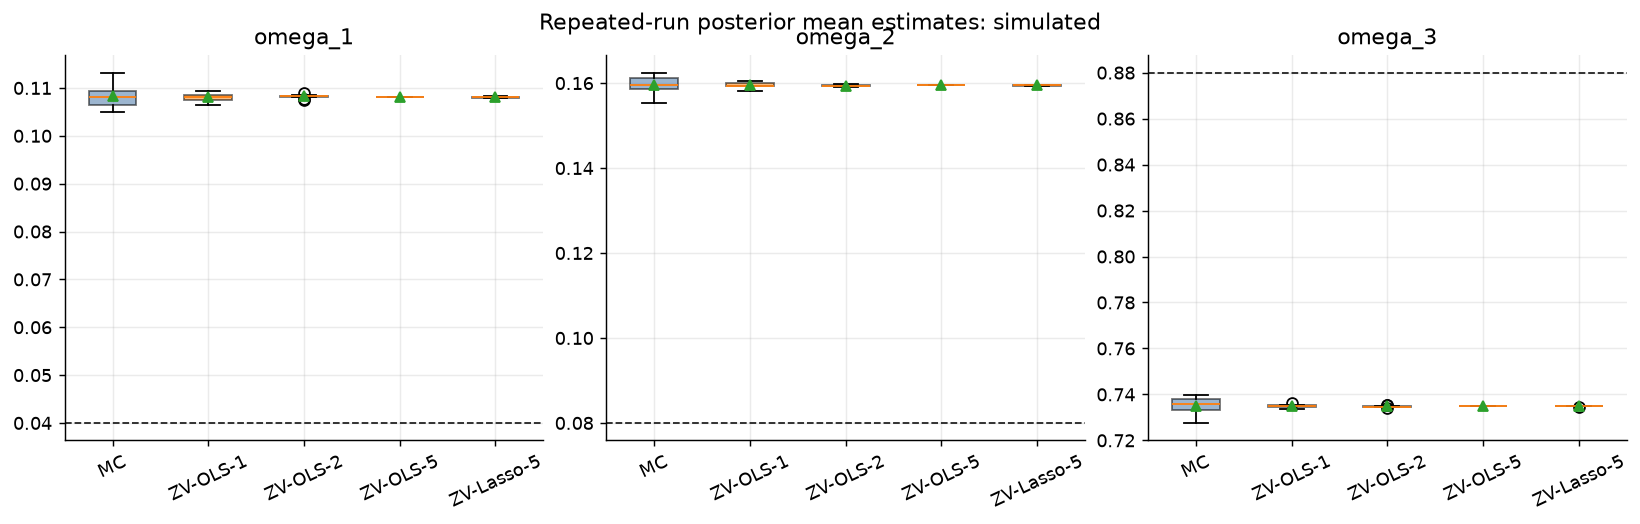

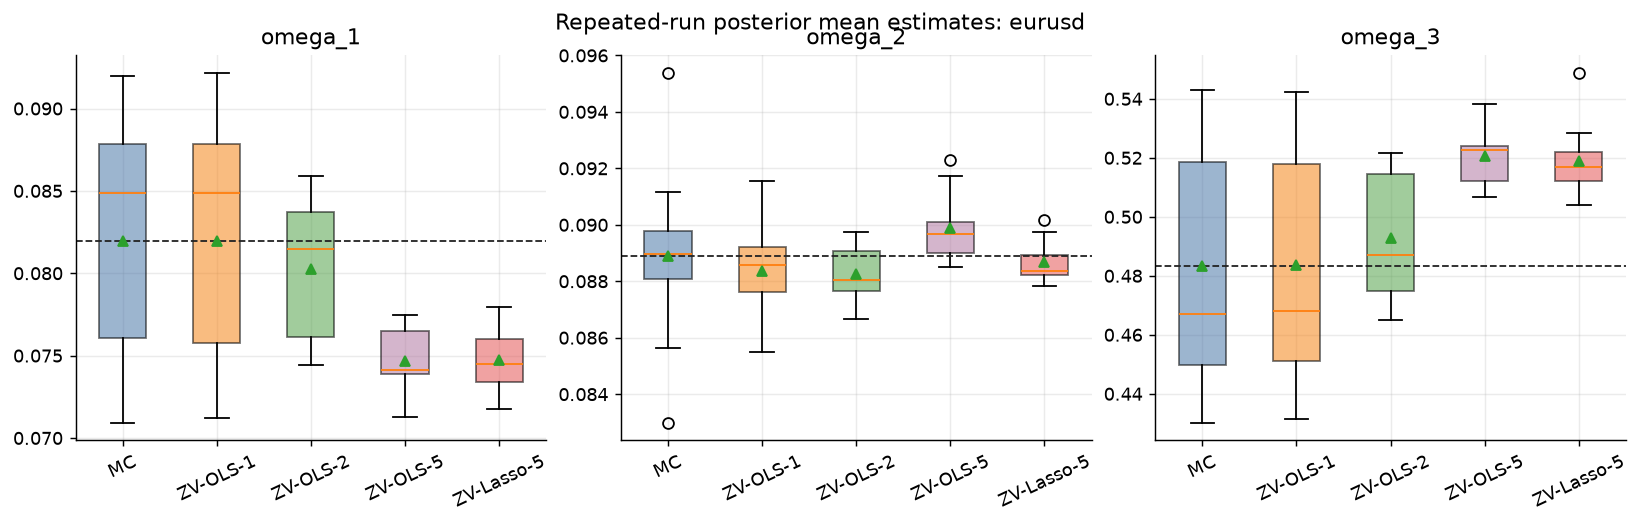

In [9]:
method_order = ["MC", "ZV-OLS-1", "ZV-OLS-2", f"ZV-OLS-{LARGE_DEGREE}", f"ZV-Lasso-{LARGE_DEGREE}"]
colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756"]

def plot_boxplots(dataset, path_base):
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), constrained_layout=True)
    for j, param in enumerate(g.PARAMETER_NAMES):
        ax = axes[j]
        data = [
            estimates[
                (estimates["dataset"] == dataset) &
                (estimates["parameter"] == param) &
                (estimates["method"] == method)
            ]["estimate"].to_numpy()
            for method in method_order
        ]
        bp = ax.boxplot(data, tick_labels=method_order, patch_artist=True, showmeans=True)
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.55)
        ref = reference[(dataset, param)]
        ax.axhline(ref, color="#222222", lw=1.0, ls="--", label="reference")
        ax.set_title(param)
        ax.tick_params(axis="x", rotation=25)
    fig.suptitle(f"Repeated-run posterior mean estimates: {dataset}", y=1.02)
    fig.savefig(FIG_DIR / f"{path_base}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{path_base}.png", bbox_inches="tight")
    plt.show()

plot_boxplots("simulated", "boxplots_simulated")
plot_boxplots("eurusd", "boxplots_eurusd")

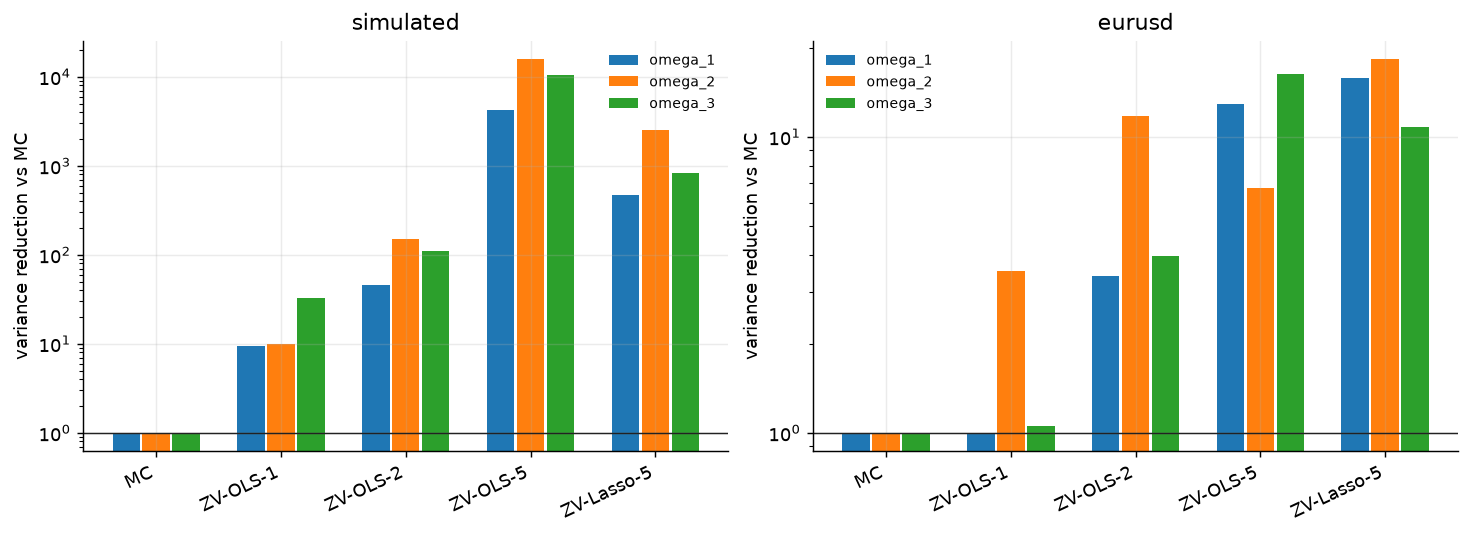

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4), constrained_layout=True)
for ax, dataset in zip(axes, ["simulated", "eurusd"]):
    subset = summary[summary["dataset"] == dataset].copy()
    for j, param in enumerate(g.PARAMETER_NAMES):
        vals = [
            subset[
                (subset["parameter"] == param) &
                (subset["method"] == method)
            ]["variance_reduction"].iloc[0]
            for method in method_order
        ]
        x = np.arange(len(method_order)) + 0.24 * (j - 1)
        ax.bar(x, vals, width=0.22, label=param)
    ax.axhline(1.0, color="#222222", lw=0.8)
    ax.set_yscale("log")
    ax.set_xticks(np.arange(len(method_order)))
    ax.set_xticklabels(method_order, rotation=25, ha="right")
    ax.set_title(dataset)
    ax.set_ylabel("variance reduction vs MC")
    ax.legend(frameon=False, fontsize=8)
fig.savefig(FIG_DIR / "variance_reduction.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "variance_reduction.png", bbox_inches="tight")
plt.show()

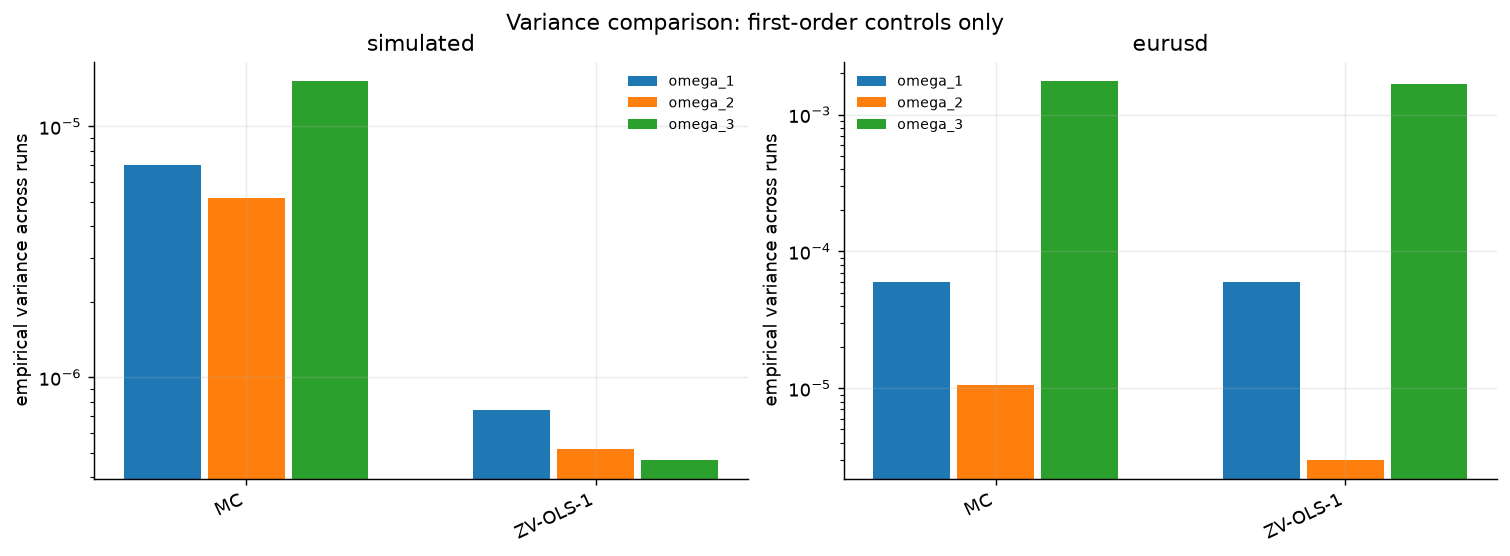

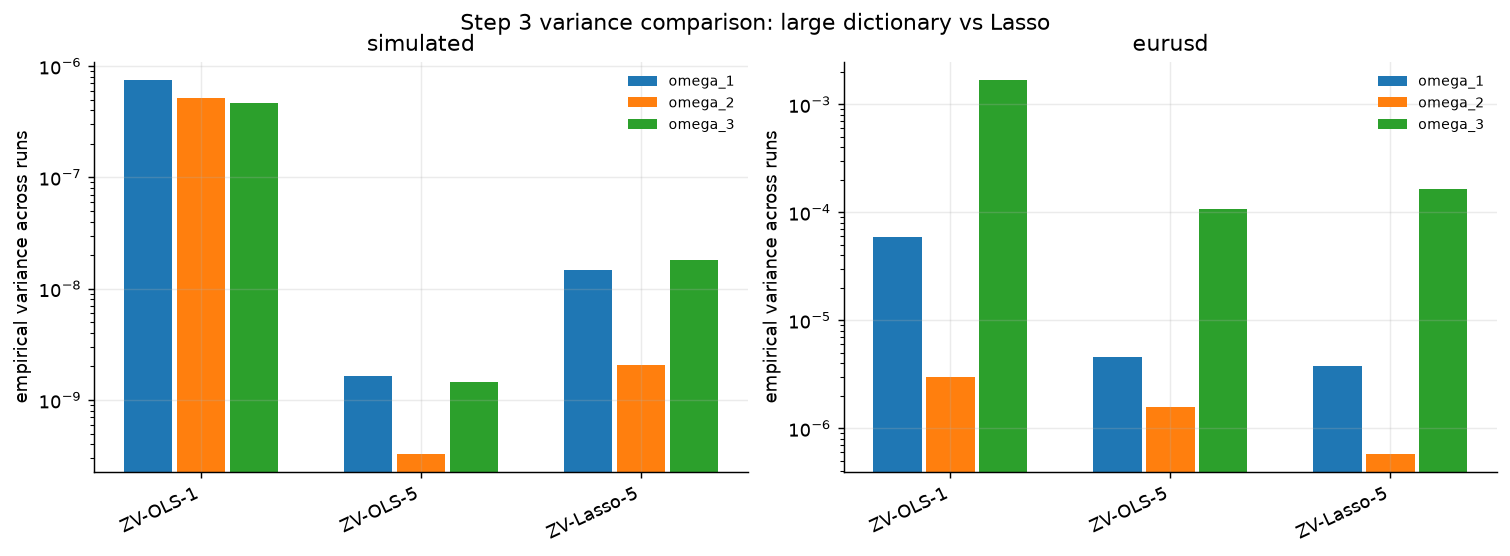

In [11]:
def plot_variance_subset(methods, filename, title):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4), constrained_layout=True)
    for ax, dataset in zip(axes, ["simulated", "eurusd"]):
        subset = summary[(summary["dataset"] == dataset) & (summary["method"].isin(methods))].copy()
        for j, param in enumerate(g.PARAMETER_NAMES):
            vals = [
                subset[
                    (subset["parameter"] == param) &
                    (subset["method"] == method)
                ]["numerical_sd"].iloc[0] ** 2
                for method in methods
            ]
            x = np.arange(len(methods)) + 0.24 * (j - 1)
            ax.bar(x, vals, width=0.22, label=param)
        ax.set_yscale("log")
        ax.set_xticks(np.arange(len(methods)))
        ax.set_xticklabels(methods, rotation=25, ha="right")
        ax.set_title(dataset)
        ax.set_ylabel("empirical variance across runs")
        ax.legend(frameon=False, fontsize=8)
    fig.suptitle(title, y=1.03)
    fig.savefig(FIG_DIR / f"{filename}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{filename}.png", bbox_inches="tight")
    plt.show()

plot_variance_subset(["MC", "ZV-OLS-1"], "first_order_variance_only", "Variance comparison: first-order controls only")
plot_variance_subset(["ZV-OLS-1", f"ZV-OLS-{LARGE_DEGREE}", f"ZV-Lasso-{LARGE_DEGREE}"], "step3_variance_comparison", "Step 3 variance comparison: large dictionary vs Lasso")

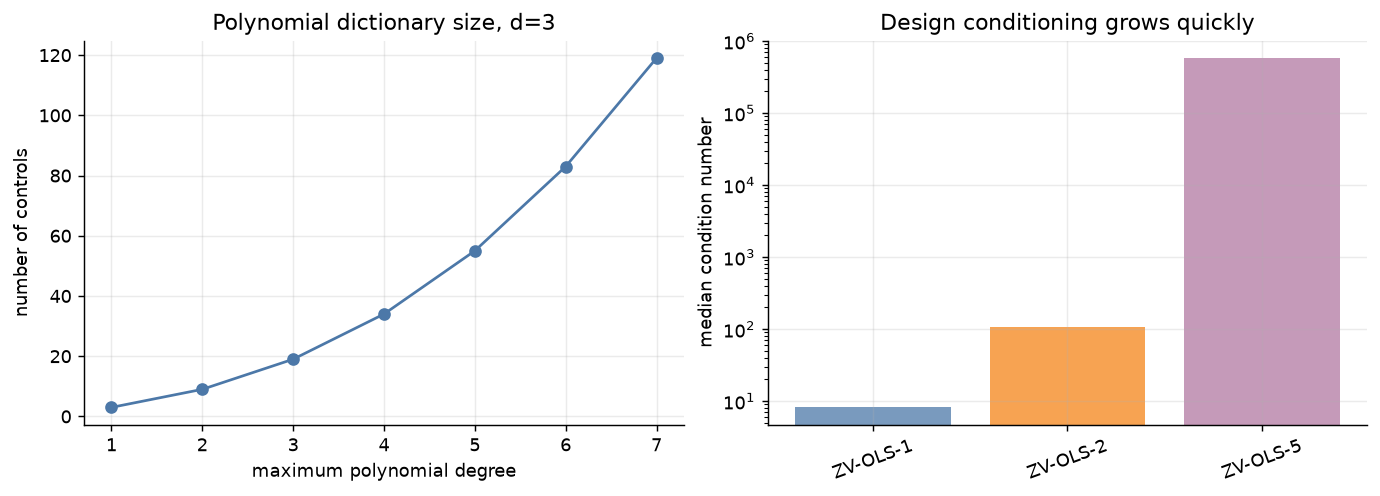

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.7), constrained_layout=True)
ax[0].plot(controls_growth["degree"], controls_growth["number_of_controls"], marker="o", color="#4C78A8")
ax[0].set_title("Polynomial dictionary size, d=3")
ax[0].set_xlabel("maximum polynomial degree")
ax[0].set_ylabel("number of controls")

cond_subset = summary[summary["method"].isin(["ZV-OLS-1", "ZV-OLS-2", f"ZV-OLS-{LARGE_DEGREE}"])]
labels = ["ZV-OLS-1", "ZV-OLS-2", f"ZV-OLS-{LARGE_DEGREE}"]
cond_vals = [
    cond_subset[
        (cond_subset["dataset"] == "simulated") &
        (cond_subset["parameter"] == "omega_1") &
        (cond_subset["method"] == method)
    ]["median_condition"].iloc[0]
    for method in labels
]
ax[1].bar(labels, cond_vals, color=["#4C78A8", "#F58518", "#B279A2"], alpha=0.75)
ax[1].set_yscale("log")
ax[1].set_title("Design conditioning grows quickly")
ax[1].set_ylabel("median condition number")
ax[1].tick_params(axis="x", rotation=20)
fig.savefig(FIG_DIR / "control_dictionary_cost.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "control_dictionary_cost.png", bbox_inches="tight")
plt.show()

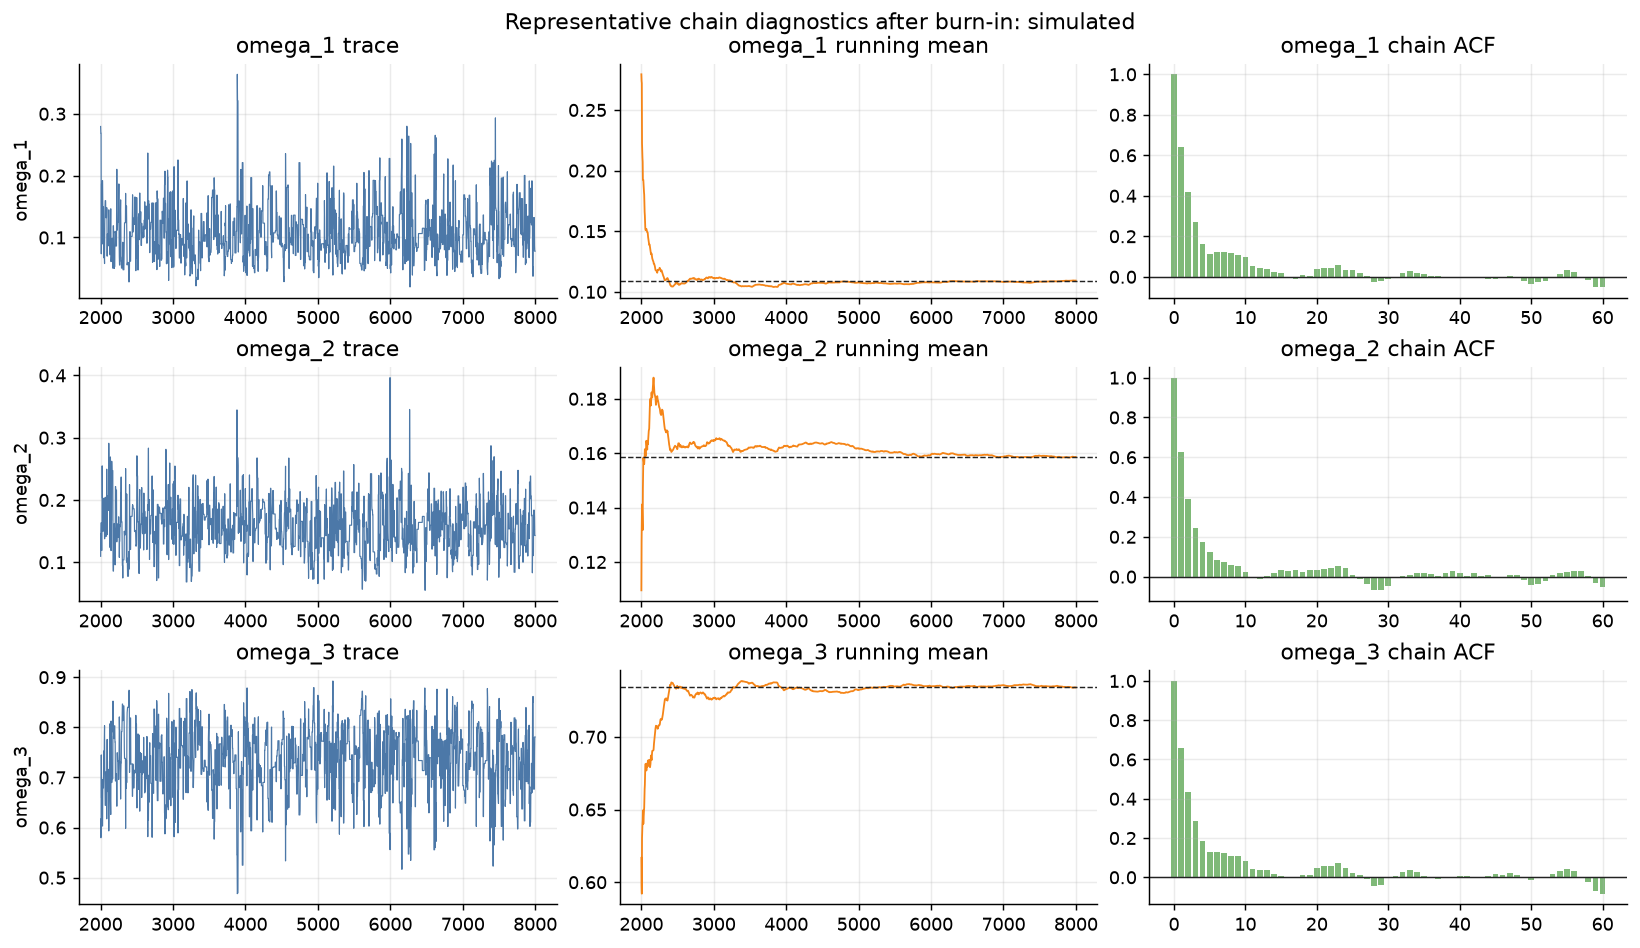

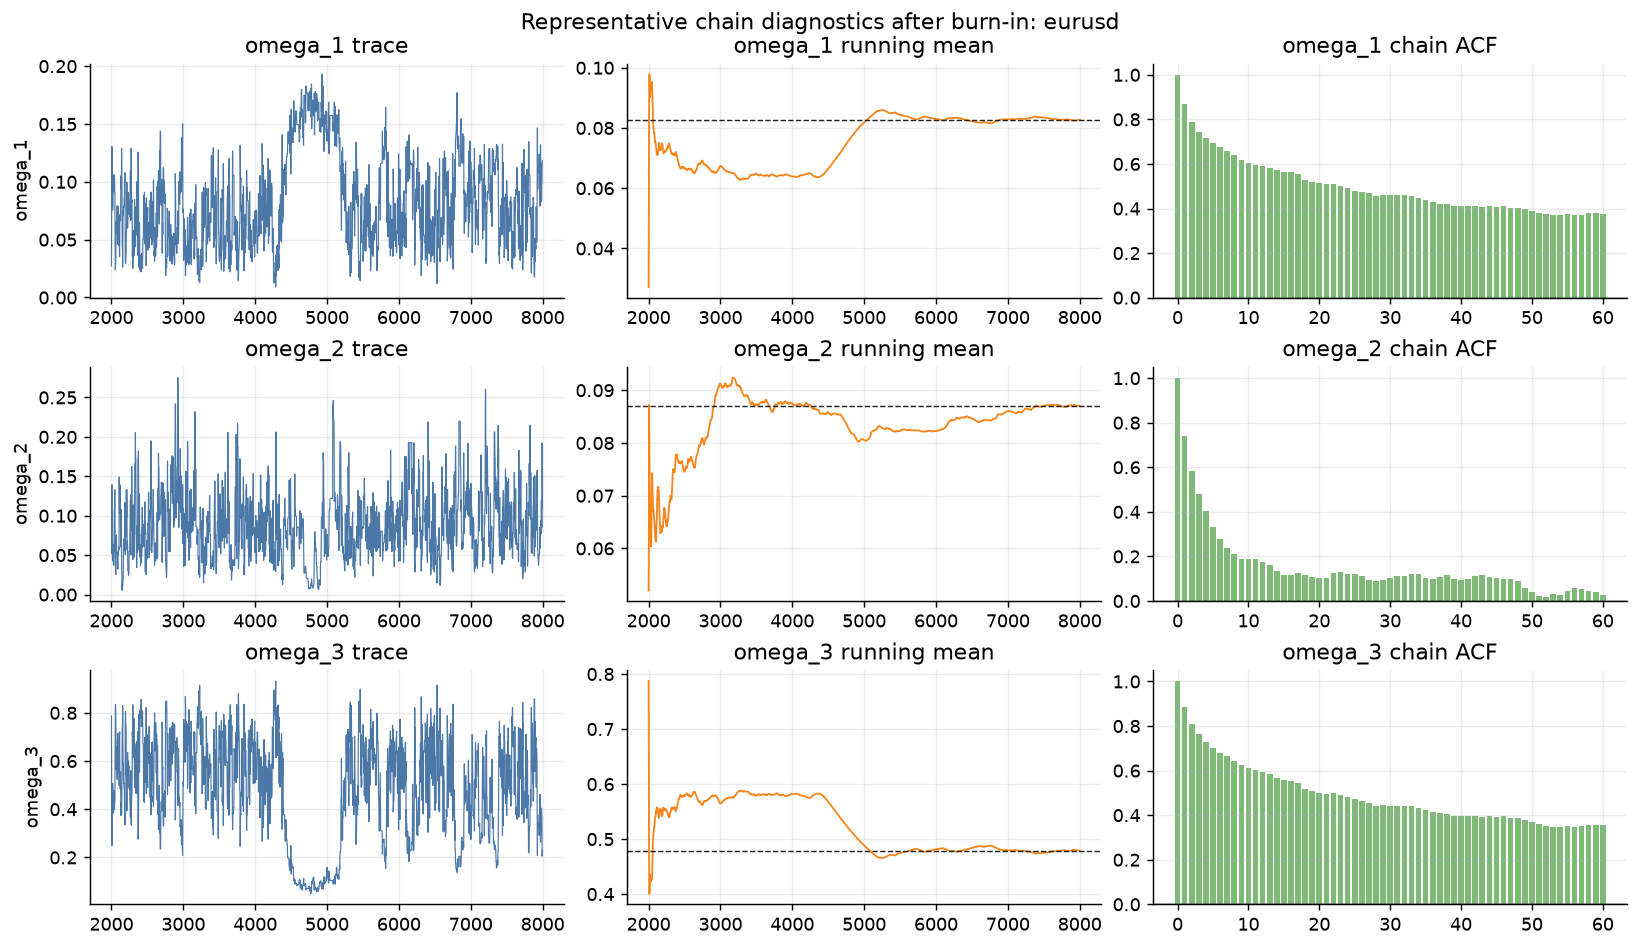

In [13]:
def plot_representative_chain(dataset, path_base):
    result = representatives[dataset]
    fig, axes = plt.subplots(3, 3, figsize=(12.5, 7.0), constrained_layout=True)
    x_axis = np.arange(result.omega.shape[0]) * THIN + BURN_IN
    for j, param in enumerate(g.PARAMETER_NAMES):
        series = result.omega[:, j]
        running_mean = np.cumsum(series) / np.arange(1, series.size + 1)
        acf = g.autocorrelation(series, max_lag=60)
        axes[j, 0].plot(x_axis, series, lw=0.65, color="#4C78A8")
        axes[j, 0].set_ylabel(param)
        axes[j, 0].set_title(f"{param} trace")
        axes[j, 1].plot(x_axis, running_mean, lw=1.0, color="#F58518")
        axes[j, 1].axhline(running_mean[-1], color="#222222", lw=0.8, ls="--")
        axes[j, 1].set_title(f"{param} running mean")
        axes[j, 2].bar(np.arange(acf.size), acf, color="#54A24B", alpha=0.75)
        axes[j, 2].axhline(0.0, color="#222222", lw=0.8)
        axes[j, 2].set_title(f"{param} chain ACF")
    fig.suptitle(f"Representative chain diagnostics after burn-in: {dataset}", y=1.02)
    fig.savefig(FIG_DIR / f"{path_base}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{path_base}.png", bbox_inches="tight")
    plt.show()

plot_representative_chain("simulated", "chain_simulated")
plot_representative_chain("eurusd", "chain_eurusd")

The traces are random-walk Metropolis paths after burn-in.  Short-range upward or downward runs are expected because the samples are autocorrelated.  The relevant diagnostic is whether the running mean stabilizes and whether repeated independent chains give similar final averages; this is why the notebook uses longer chains and reports repeated-run boxplots.

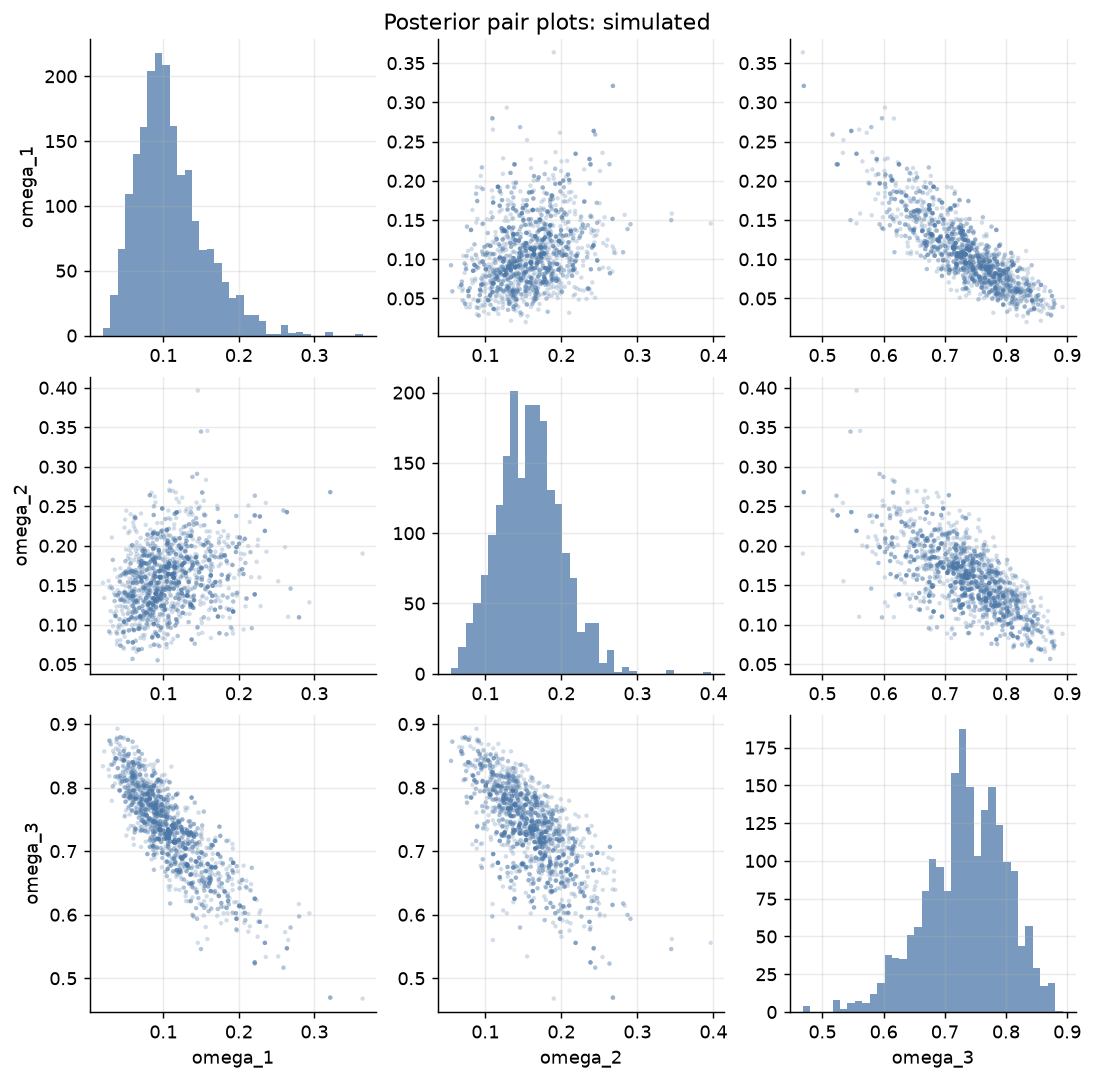

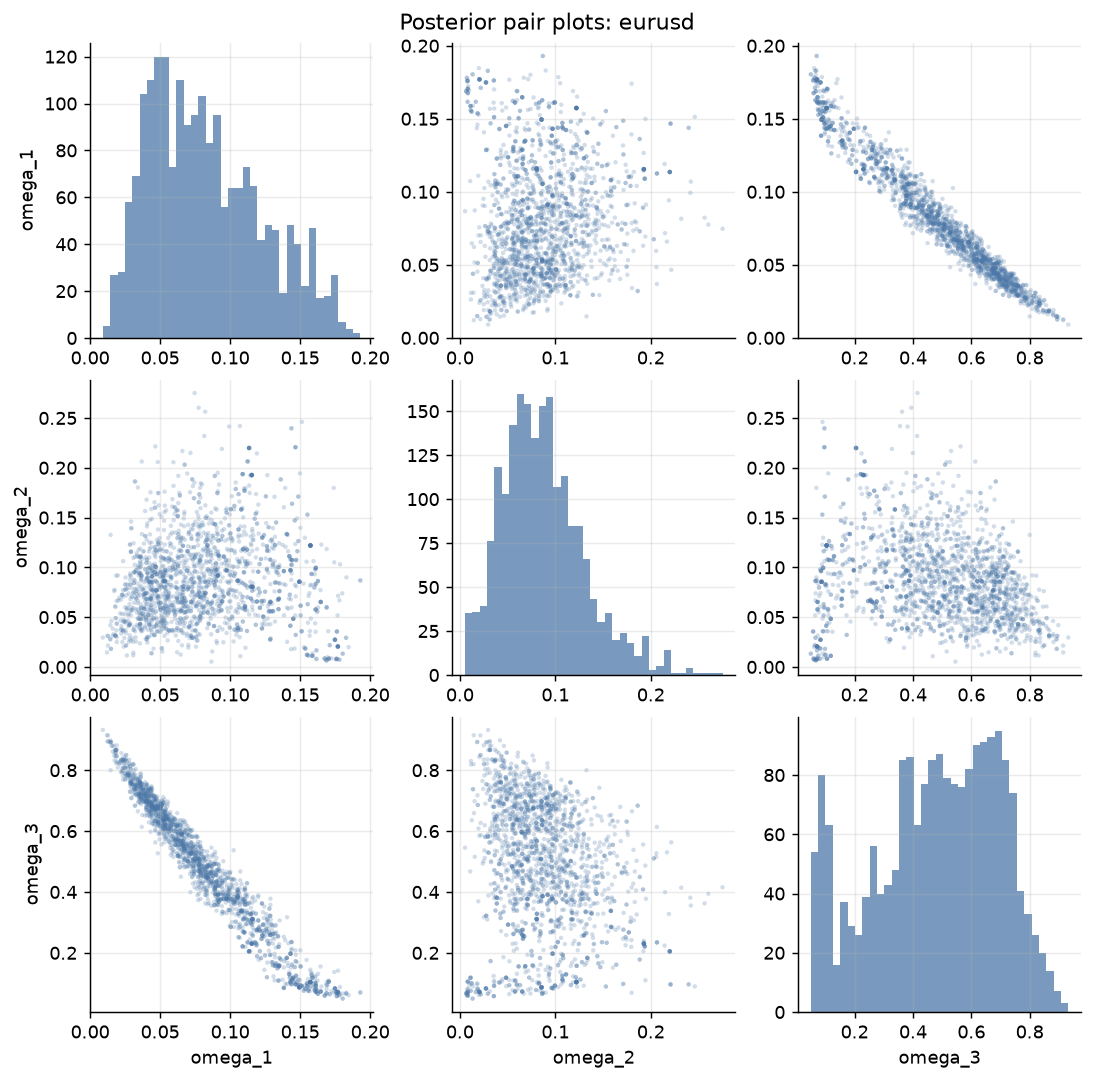

In [14]:
def plot_posterior_pairs(dataset, path_base):
    result = representatives[dataset]
    omega = result.omega
    step = max(1, omega.shape[0] // 1200)
    sampled = omega[::step]
    fig, axes = plt.subplots(3, 3, figsize=(8.3, 8.0), constrained_layout=True)
    for i, row_param in enumerate(g.PARAMETER_NAMES):
        for j, col_param in enumerate(g.PARAMETER_NAMES):
            ax = axes[i, j]
            if i == j:
                ax.hist(sampled[:, j], bins=35, color="#4C78A8", alpha=0.75)
            else:
                ax.scatter(sampled[:, j], sampled[:, i], s=6, alpha=0.25, color="#4C78A8", edgecolors="none")
            if i == 2:
                ax.set_xlabel(col_param)
            if j == 0:
                ax.set_ylabel(row_param)
    fig.suptitle(f"Posterior pair plots: {dataset}", y=1.02)
    fig.savefig(FIG_DIR / f"{path_base}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{path_base}.png", bbox_inches="tight")
    plt.show()

plot_posterior_pairs("simulated", "posterior_pairs_simulated")
plot_posterior_pairs("eurusd", "posterior_pairs_eurusd")

## Numerical error assessment

The following tables summarize the repeated-run distribution.  The column `sd across runs` is the empirical standard deviation of the final estimate over the independent chains.  The boxplots above visualize the same numerical error directly.  `var. red.` is the empirical variance ratio relative to raw Monte Carlo, for the same parameter and dataset.

In [15]:
display_cols = ["dataset", "parameter", "method", "mean_estimate", "numerical_sd", "rmse_to_reference", "variance_reduction", "mean_selected", "mean_acceptance"]
summary[display_cols].sort_values(["dataset", "parameter", "method"])

,dataset,parameter,method,mean_estimate,numerical_sd,rmse_to_reference,variance_reduction,mean_selected,mean_acceptance
0,eurusd,omega_1,MC,0.081957,0.007720,0.007324,1.000000,0.0,0.362513
1,eurusd,omega_1,ZV-Lasso-5,0.074761,0.001943,0.007428,15.782792,41.2,0.362513
2,eurusd,omega_1,ZV-OLS-1,0.081986,0.007716,0.007320,1.001035,3.0,0.362513
3,eurusd,omega_1,ZV-OLS-2,0.080273,0.004199,0.004325,3.379594,9.0,0.362513
4,eurusd,omega_1,ZV-OLS-5,0.074665,0.002148,0.007571,12.919883,55.0,0.362513
5,eurusd,omega_2,MC,0.088909,0.003257,0.003090,1.000000,0.0,0.362513
6,eurusd,omega_2,ZV-Lasso-5,0.088667,0.000762,0.000762,18.293031,30.0,0.362513
7,eurusd,omega_2,ZV-OLS-1,0.088357,0.001733,0.001735,3.531305,3.0,0.362513
8,eurusd,omega_2,ZV-OLS-2,0.088264,0.000951,0.001109,11.724723,9.0,0.362513
9,eurusd,omega_2,ZV-OLS-5,0.089895,0.001258,0.001548,6.705057,55.0,0.362513


## Why Lasso is useful here

For \(d=3\), all non-constant monomials up to total degree \(q\) already produce
\[
\binom{d+q}{d}-1
\]
candidate controls.  This is moderate for \(q=2\), but the growth is combinatorial in dimension and degree.  Ordinary least squares on all controls can become expensive and unstable because the design matrix becomes wide and highly collinear.  The post-Lasso approach screens a large dictionary, keeps a smaller active set, and then performs the usual OLS control-variate regression on that active set.

In [16]:
controls_growth

,degree,number_of_controls
0,1,3
1,2,9
2,3,19
3,4,34
4,5,55
5,6,83
6,7,119


## Regression on dependent MCMC output

Ordinary linear regression formulas are derived for independent observations.  MCMC samples are dependent, so the usual regression standard errors are not valid.  The control-variate estimator itself is still meaningful under the same type of ergodic-average conditions used for MCMC central limit theorems, but its Monte Carlo error must be assessed with MCMC-aware methods.

Practical fixes:

- estimate the control coefficients on a pilot chain and evaluate the controlled estimator on a second independent chain;
- thin or subsample the chain when fitting the regression, which reduces dependence at the cost of fewer fitting points;
- use batch means or spectral variance estimators for the final numerical standard error;
- use block cross-validation for Lasso, so adjacent dependent observations do not appear in both training and validation folds.

The notebook reports batch-means standard errors in the tables and, more importantly, independent repeated-chain boxplots.

In [17]:
bonus_rows = []
dataset = "simulated"
returns = simulated_returns
result = representatives[dataset]
grad = g.grad_log_posterior_theta_batch(returns, result.theta)
Hlarge, _, _ = g.zv_controls(result.theta, grad, degree=LARGE_DEGREE)
for j, param in enumerate(g.PARAMETER_NAMES):
    y = result.omega[:, j]
    full = g.controlled_estimate_ols(y, Hlarge)
    thinned = g.controlled_estimate_ols(y[::5], Hlarge[::5])
    bonus_rows.append({
        "parameter": param,
        "full_sample_estimate": full.estimate,
        "full_batch_se": g.batch_means_se(full.controlled_values, batch_size=80),
        "thin5_estimate": thinned.estimate,
        "thin5_batch_se": g.batch_means_se(thinned.controlled_values, batch_size=30),
    })

bonus_table = pd.DataFrame(bonus_rows)
bonus_table.to_csv(RESULT_DIR / "bonus_thinning.csv", index=False)
bonus_table.to_latex(RESULT_DIR / "bonus_thinning.tex", index=False, escape=True)
bonus_table

,parameter,full_sample_estimate,full_batch_se,thin5_estimate,thin5_batch_se
0,omega_1,0.108077,0.000007,0.108016,0.000010
1,omega_2,0.159494,0.000003,0.159499,0.000002
2,omega_3,0.734894,0.000007,0.734954,0.000010


## Main takeaways

- The random-walk Metropolis sampler targets the transformed GARCH posterior and gives interpretable posterior summaries in \(\omega\).
- First-order zero-variance controls are easy to implement once \(\nabla\log\pi\) is available.
- Larger polynomial dictionaries can reduce variance further, but the OLS design quickly becomes ill-conditioned.
- Lasso screening is a practical way to use a large candidate dictionary without relying on the full unstable regression.
- Numerical error should be reported from repeated chains or MCMC-aware standard errors, not from iid regression formulas.